# KG setup

In [1]:
import networkx as nx
import random

random.seed(0)

cities = ["Paris", "Tokyo", "Cairo", "Lima", "Oslo", "Madrid", "Seoul",
          "Nairobi", "Toronto", "Athens", "Dublin", "Hanoi", "Quito",
          "Vienna", "Lagos", "Perth", "Bogota", "Prague", "Manila",
          "Havana", "Riga", "Tunis", "Osaka", "Denver", "Geneva",
          "Mumbai", "Dakar", "Seville", "Krakow", "Austin"]

# plausible for any pair, but no confident pretraining prior for specific pairs
relations = ["trades-with", "is-allied-with", "exchanges-students-with"]

G = nx.random_regular_graph(d=4, n=len(cities), seed=0)
G = nx.relabel_nodes(G, dict(enumerate(cities)))
for u, v in G.edges:
    G.edges[u, v]["relation"] = random.choice(relations)

triples = [f"{u} {G.edges[u,v]['relation']} {v}." for u, v in G.edges]
random.shuffle(triples)
prompt = "\n".join(triples)
print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(prompt[:400])

30 nodes, 60 edges
Hanoi exchanges-students-with Riga.
Nairobi exchanges-students-with Perth.
Oslo exchanges-students-with Austin.
Paris is-allied-with Vienna.
Lagos exchanges-students-with Seville.
Geneva exchanges-students-with Krakow.
Athens is-allied-with Mumbai.
Seoul trades-with Seville.
Toronto exchanges-students-with Tunis.
Seoul exchanges-students-with Nairobi.
Perth trades-with Tunis.
Cairo trades-with Qui


# Model loading & setup

In [2]:
import torch
import os
os.environ["HF_HOME"] = "/workspace/hf"
os.environ["HF_TOKEN"] = open("/workspace/.hf_token").read().strip()

from transformer_lens import HookedTransformer
model = HookedTransformer.from_pretrained_no_processing("gemma-2-2b", dtype=torch.bfloat16)

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Loaded pretrained model gemma-2-2b into HookedTransformer


# Token prep

In [5]:
token_ids = model.to_tokens(prompt)
str_toks = model.to_str_tokens(token_ids[0])
token_ids_cpu_copy = token_ids[0].tolist()

entity_positions = {c: [] for c in cities}
for city in cities:
    for variant in [city, " " + city]:
        city_tokens = model.to_tokens(variant, prepend_bos=False)[0].tolist()
        n = len(city_tokens)
        for i in range(len(token_ids_cpu_copy) - n + 1):
            if token_ids_cpu_copy[i:i+n] == city_tokens:
                entity_positions[city].append(i + n - 1)

for c in cities[:3]:
    print(c, entity_positions[c], [str_toks[p] for p in entity_positions[c]])

Paris [29, 116, 164, 210] ['Paris', 'Paris', 'Paris', 'Paris']
Tokyo [346, 384, 431, 525] ['Tokyo', 'Tokyo', 'Tokyo', 'Tokyo']
Cairo [99, 182, 267, 471] ['Cairo', 'Cairo', 'Cairo', 'Cairo']


# Getting activations at 4 layers

In [ ]:
layers = [6, 13, 19, 25] #26 layers in gemma-2-2b 
_, cache = model.run_with_cache(token_ids)

entity_vecs = {}  
for layer in layers:
    resid = cache["resid_post", layer][0].float()
    entity_vecs[layer] = {c: resid[entity_positions[c]].mean(0).cpu().numpy() for c in cities}

# PCA

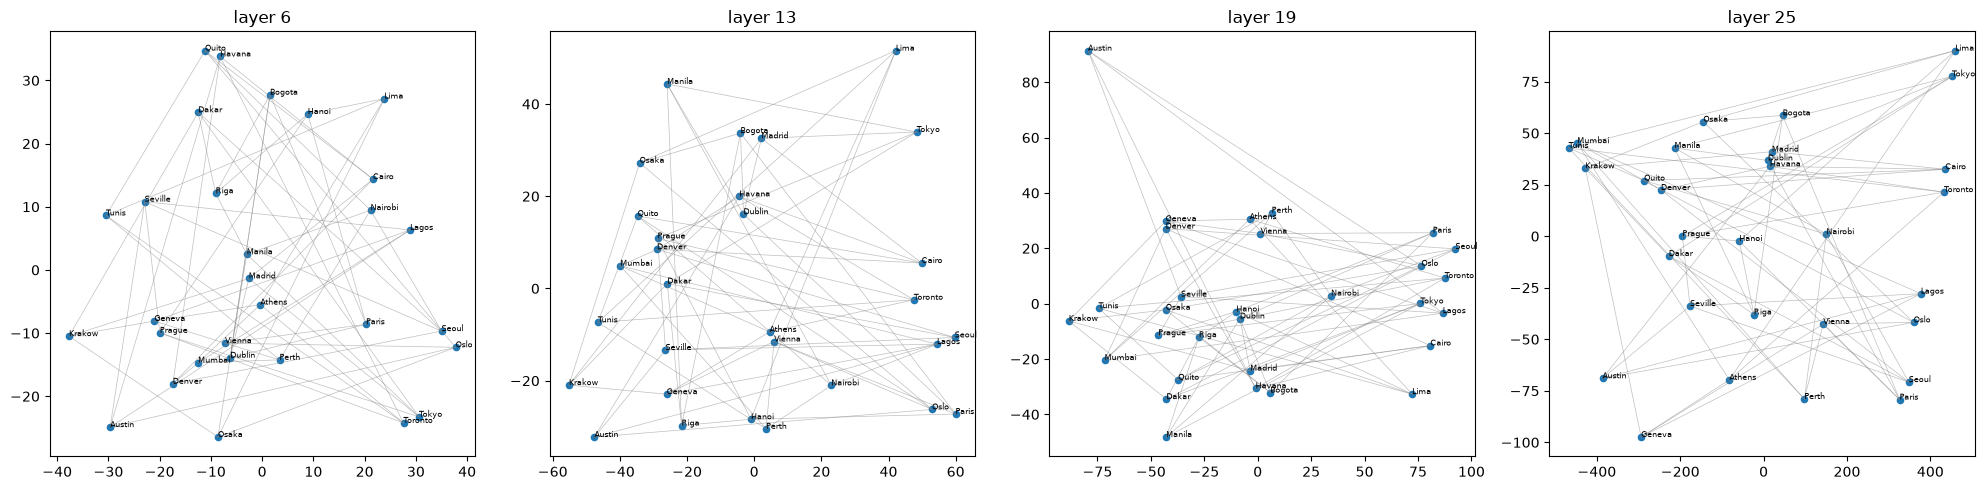

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, len(layers), figsize=(5*len(layers), 5))
for ax, layer in zip(axes, layers):
    X = np.stack([entity_vecs[layer][c] for c in cities])
    X = X - X.mean(0)
    P = PCA(n_components=2).fit_transform(X)
    pos = {c: P[i] for i, c in enumerate(cities)}
    for u, v in G.edges:                          # draw graph edges
        ax.plot(*zip(pos[u], pos[v]), color="gray", lw=0.5, alpha=0.5)
    ax.scatter(P[:, 0], P[:, 1], s=20)
    for c in cities:
        ax.annotate(c, pos[c], fontsize=6)
    ax.set_title(f"layer {layer}")
plt.tight_layout()
plt.savefig("plots_probe_icl.png", dpi=150)
plt.show()

In [ ]:
#checking pca variance ratio for each layer
for layer in layers:
    X = np.stack([entity_vecs[layer][c] for c in cities])
    X = X - X.mean(0)
    pca = PCA(n_components=10).fit(X)
    r = pca.explained_variance_ratio_
    print(f"layer {layer}: PC1+PC2 = {r[0]+r[1]:.1%}   top10: {[f'{x:.1%}' for x in r]}")

layer 6: PC1+PC2 = 17.2%   top10: ['9.7%', '7.5%', '5.8%', '5.4%', '5.1%', '4.9%', '4.8%', '4.2%', '3.9%', '3.7%']
layer 13: PC1+PC2 = 27.1%   top10: ['18.8%', '8.3%', '6.5%', '6.2%', '5.5%', '4.7%', '4.3%', '4.0%', '3.5%', '3.3%']
layer 19: PC1+PC2 = 28.4%   top10: ['22.9%', '5.5%', '5.0%', '4.5%', '4.3%', '3.9%', '3.8%', '3.8%', '3.7%', '3.5%']
layer 25: PC1+PC2 = 83.8%   top10: ['81.3%', '2.5%', '2.0%', '1.6%', '1.2%', '1.1%', '1.0%', '0.9%', '0.8%', '0.7%']


# RSA

In [9]:
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr
import networkx as nx

gd = dict(nx.all_pairs_shortest_path_length(G))
pairs = [(u, v) for i, u in enumerate(cities) for v in cities[i+1:]]
graph_d = [gd[u][v] for u, v in pairs]

for layer in layers:
    X = np.stack([entity_vecs[layer][c] for c in cities])
    act_d = pdist(X - X.mean(0))          # pairwise distances, all dims
    rho, p = spearmanr(act_d, graph_d)
    print(f"layer {layer}: spearman rho={rho:.3f}, p={p:.3f}")

layer 6: spearman rho=-0.093, p=0.051
layer 13: spearman rho=-0.041, p=0.393
layer 19: spearman rho=-0.074, p=0.123
layer 25: spearman rho=-0.079, p=0.098
